#### Loan Amount Prediction with German Credit Data
This notebook demonstrates how to build a regression model to predict the loan (credit) amount a customer may borrow, using the UCI Statlog (German Credit Data) dataset.

In [22]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
# Download the German Credit Data from UCI repository
import urllib.request
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
output_path = 'german.data'
urllib.request.urlretrieve(url, output_path)
print('Downloaded german.data')

Downloaded german.data


In [24]:
# Load the downloaded german.data file into a pandas DataFrame
columns = ['Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 'Savings', 'Employment', 'InstallmentRate', 'Personal', 'OtherDebtors', 'ResidenceSince', 'Property', 'Age', 'OtherInstallmentPlans', 'Housing', 'ExistingCredits', 'Job', 'NumPeopleLiable', 'Telephone', 'ForeignWorker', 'Target']
df = pd.read_csv('german.data', sep=' ', names=columns)
df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,Personal,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,NumPeopleLiable,Telephone,ForeignWorker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### German Credit Data Columns Description
| Column                | Description | Purpose | Typical Values & Description |
|-----------------------|-------------|---------|-----------------------------|
| Status                | Status of existing checking account | Financial status indicator | A11: no account, A12: <0 DM, A13: 0-200 DM, A14: >200 DM |
| Duration              | Duration in months | Loan term | 12, 24, 36: short/medium/long term |
| CreditHistory         | Credit history record | Creditworthiness | A30: no credits, A31: all paid, A32: existing paid, A33: delay, A34: critical |
| Purpose               | Purpose of the loan | Reason for loan | A40: car, A41: furniture, A42: radio/TV, A43: education, A44: retraining, A45: business, A46: others |
| CreditAmount          | Loan amount (DM) | Target for regression | 1000, 2500, 5000: typical loan amounts |
| Savings               | Savings account/bonds status | Financial reserves | A61: <100 DM, A62: 100-500 DM, A63: 500-1000 DM, A64: >1000 DM, A65: unknown |
| Employment            | Present employment since | Job stability | A71: unemployed, A72: <1 year, A73: 1-4 years, A74: 4-7 years, A75: >7 years |
| InstallmentRate       | Installment rate (% of income) | Repayment burden | 2, 3, 4: typical rates |
| Personal              | Personal status and sex | Demographics | A91: male single, A92: male married, A93: male divorced, A94: female single, A95: female divorced/married |
| OtherDebtors          | Other debtors/guarantors | Financial support | A101: none, A102: co-applicant, A103: guarantor |
| ResidenceSince        | Present residence since (years) | Stability | 1, 2, 3, 4: typical years |
| Property              | Property type | Asset ownership | A121: real estate, A122: savings, A123: car, A124: unknown |
| Age                   | Age in years | Demographics | 25, 35, 50: typical ages |
| OtherInstallmentPlans | Other installment plans | Financial obligations | A141: bank, A142: stores, A143: none |
| Housing               | Housing type | Living situation | A151: own, A152: for free, A153: rent |
| ExistingCredits       | Number of existing credits | Credit exposure | 1, 2, 3, 4: typical values |
| Job                   | Job type | Employment quality | A171: unemployed, A172: unskilled resident, A173: skilled, A174: highly skilled |
| NumPeopleLiable       | Number of people liable | Financial responsibility | 1, 2: typical values |
| Telephone             | Telephone availability | Contactability | A191: none, A192: yes, registered |
| ForeignWorker         | Foreign worker status | Demographics | A201: yes, A202: no |
| Target                | Credit risk (1=good, 2=bad) | Classification target | 1: good, 2: bad |

In [25]:
# Drop the Target column (classification label) for regression tasks
df = df.drop(columns=['Target'])

# Extract numeric and categorical columns
numeric_cols     = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns: ['Duration', 'CreditAmount', 'InstallmentRate', 'ResidenceSince', 'Age', 'ExistingCredits', 'NumPeopleLiable']
Categorical columns: ['Status', 'CreditHistory', 'Purpose', 'Savings', 'Employment', 'Personal', 'OtherDebtors', 'Property', 'OtherInstallmentPlans', 'Housing', 'Job', 'Telephone', 'ForeignWorker']


#### Explore the numerical features

In [26]:
# Describe the numeric columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
CreditAmount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
InstallmentRate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
ResidenceSince,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
ExistingCredits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
NumPeopleLiable,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


##### Numeric Column Inferences
| Column           | Observation                                                                 | Data Science Angle for Regression Task                                  |
|------------------|-----------------------------------------------------------------------------|------------------------------------------------------------------------|
| Duration         | Most loans are short-term (median 18 months), but some last up to 72 months | Useful for predicting loan amount; longer duration may mean higher loan |
| CreditAmount     | Wide range, average ~3,271 DM, high std, some very large outliers           | Target variable; outliers may affect model, consider robust methods     |
| InstallmentRate  | Most customers pay 2–4% of income, median 3%                                | Indicates repayment burden; helps model affordability                   |
| ResidenceSince   | Most have lived 2–4 years at current residence                              | Stability indicator; longer residence may correlate with higher loans   |
| Age              | Median age 33, most applicants are young to middle-aged adults              | Age may affect loan eligibility and amount                              |
| ExistingCredits  | Most have only 1 existing credit, few have up to 4                          | Credit exposure; more credits may reduce loan amount                    |
| NumPeopleLiable  | Nearly all are solely liable (value = 1)                                    | Low variance; limited impact, but may indicate responsibility           |

Visualize distributions: Use histograms and boxplots for each numeric column to spot skewness and outliers.

Correlation analysis: Compute and plot the correlation matrix to see relationships between numeric features.

Pairwise scatter plots: Visualize relationships between key numeric features (e.g., Age vs CreditAmount).

Outlier detection: Identify and visualize extreme values in each column.

Grouped analysis: Compare numeric feature distributions by categories (e.g., by loan purpose or other categorical features).

#### Visualize distributions for each numeric column
- Plot histograms and boxplots
- Report skewness and outlier possibility
- Suggest data science remediations

===== Duration =====


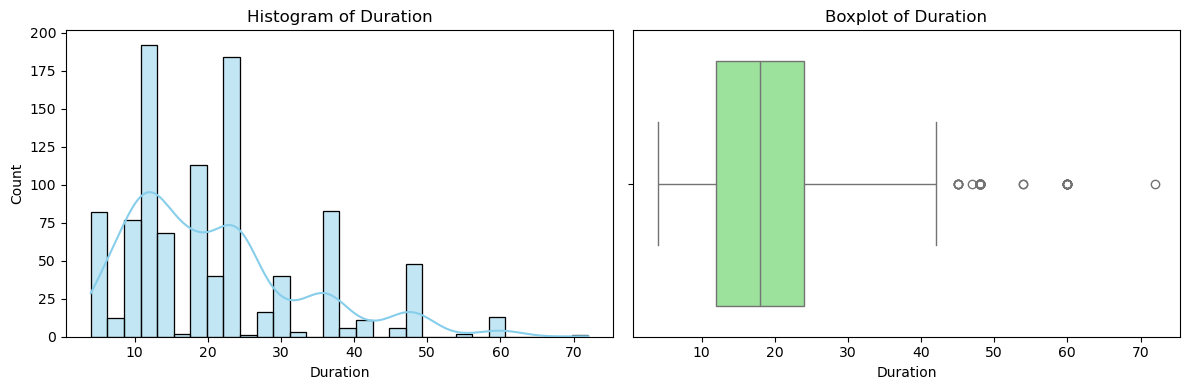

Missing values: 0
Min: 4, Max: 72
25th percentile: 12.0, Median: 18.0, 75th percentile: 24.0
Skewness: 1.09
Outlier count: 70
Correlation with CreditAmount: 0.62
Feature importance: To be determined after model training.
Domain interpretation: Add notes based on business context.
  - Highly skewed: Consider log or Box-Cox transformation.
  - Outliers detected: Consider capping, removing, or robust models.
Feature engineering: Consider scaling, binning, or interaction terms.
Model impact: Check for multicollinearity and predictive power after modeling.
--------------------------------------------------------------------------------
===== CreditAmount =====


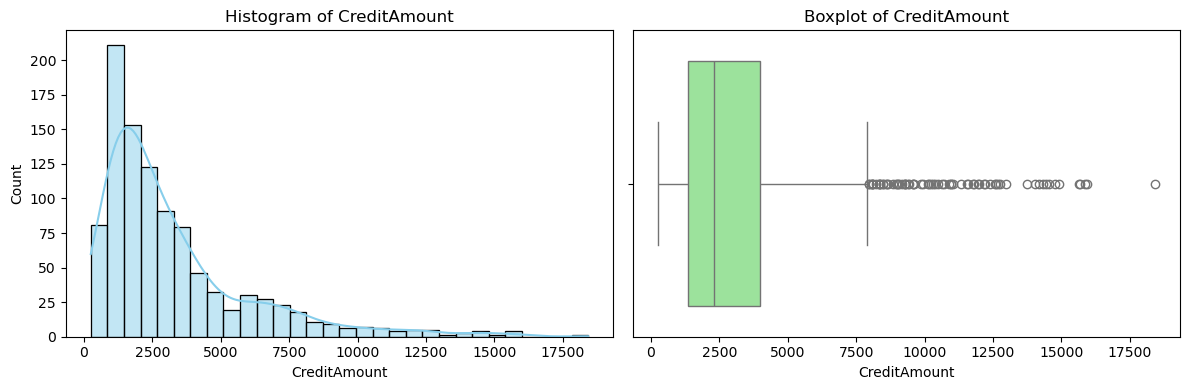

Missing values: 0
Min: 250, Max: 18424
25th percentile: 1365.5, Median: 2319.5, 75th percentile: 3972.25
Skewness: 1.95
Outlier count: 72
Feature importance: To be determined after model training.
Domain interpretation: Add notes based on business context.
  - Highly skewed: Consider log or Box-Cox transformation.
  - Outliers detected: Consider capping, removing, or robust models.
Feature engineering: Consider scaling, binning, or interaction terms.
Model impact: Check for multicollinearity and predictive power after modeling.
--------------------------------------------------------------------------------
===== InstallmentRate =====


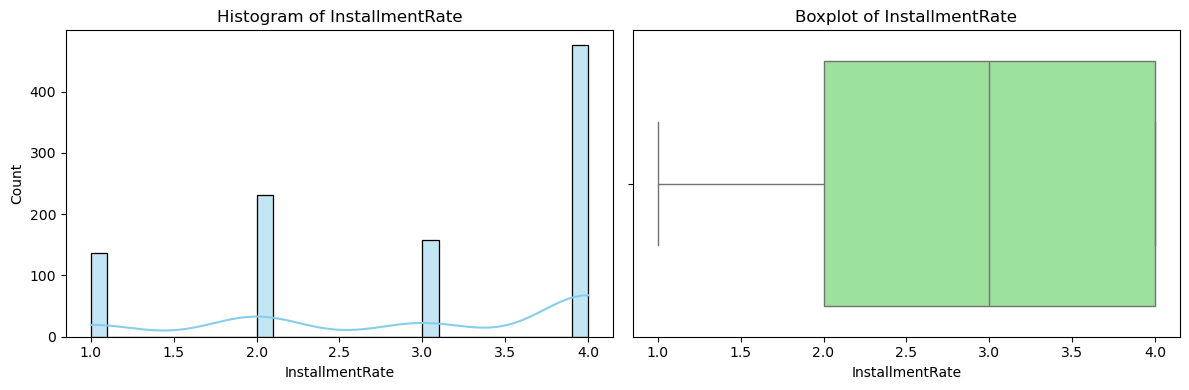

Missing values: 0
Min: 1, Max: 4
25th percentile: 2.0, Median: 3.0, 75th percentile: 4.0
Skewness: -0.53
Outlier count: 0
Correlation with CreditAmount: -0.27
Feature importance: To be determined after model training.
Domain interpretation: Add notes based on business context.
  - Moderately skewed: Consider transformation if needed.
Feature engineering: Consider scaling, binning, or interaction terms.
Model impact: Check for multicollinearity and predictive power after modeling.
--------------------------------------------------------------------------------
===== ResidenceSince =====


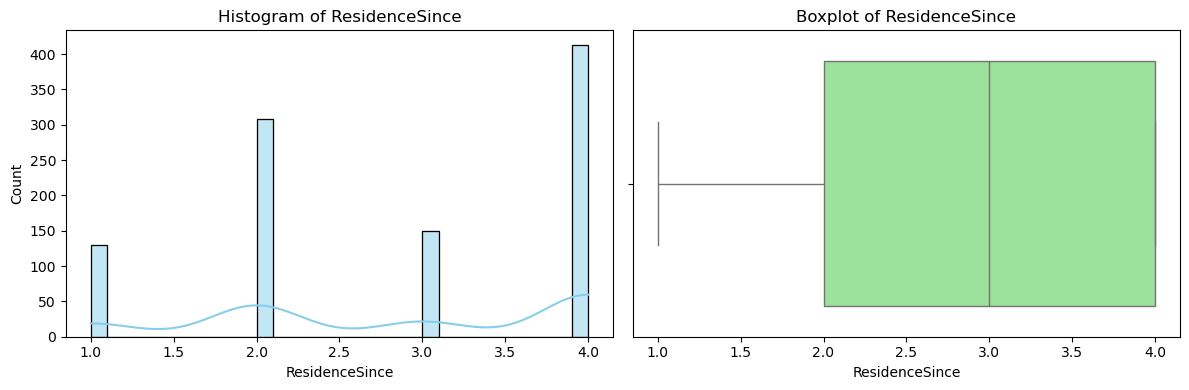

Missing values: 0
Min: 1, Max: 4
25th percentile: 2.0, Median: 3.0, 75th percentile: 4.0
Skewness: -0.27
Outlier count: 0
Correlation with CreditAmount: 0.03
Feature importance: To be determined after model training.
Domain interpretation: Add notes based on business context.
  - Symmetric distribution.
Feature engineering: Consider scaling, binning, or interaction terms.
Model impact: Check for multicollinearity and predictive power after modeling.
--------------------------------------------------------------------------------
===== Age =====


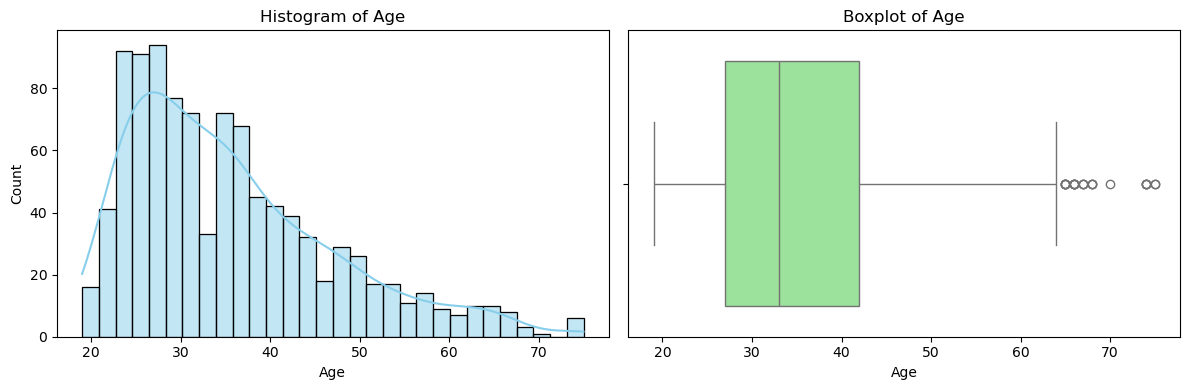

Missing values: 0
Min: 19, Max: 75
25th percentile: 27.0, Median: 33.0, 75th percentile: 42.0
Skewness: 1.02
Outlier count: 23
Correlation with CreditAmount: 0.03
Feature importance: To be determined after model training.
Domain interpretation: Add notes based on business context.
  - Highly skewed: Consider log or Box-Cox transformation.
  - Outliers detected: Consider capping, removing, or robust models.
Feature engineering: Consider scaling, binning, or interaction terms.
Model impact: Check for multicollinearity and predictive power after modeling.
--------------------------------------------------------------------------------
===== ExistingCredits =====


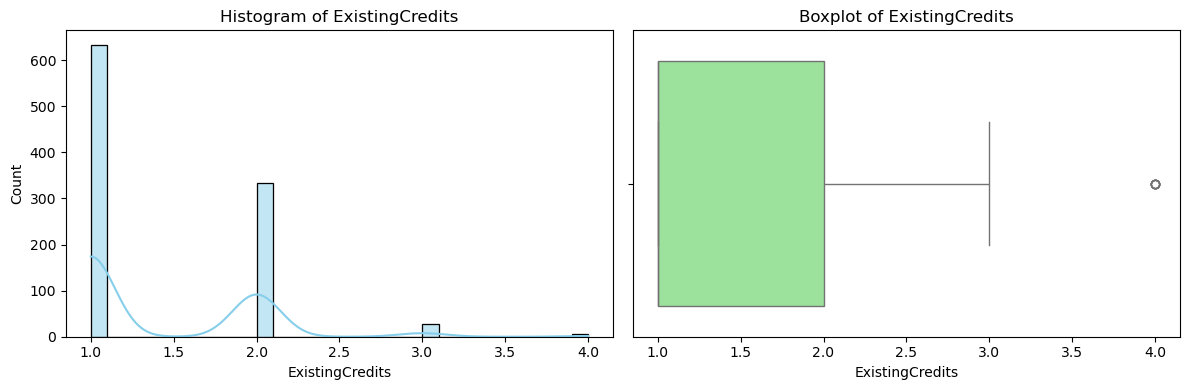

Missing values: 0
Min: 1, Max: 4
25th percentile: 1.0, Median: 1.0, 75th percentile: 2.0
Skewness: 1.27
Outlier count: 6
Correlation with CreditAmount: 0.02
Feature importance: To be determined after model training.
Domain interpretation: Add notes based on business context.
  - Highly skewed: Consider log or Box-Cox transformation.
  - Outliers detected: Consider capping, removing, or robust models.
Feature engineering: Consider scaling, binning, or interaction terms.
Model impact: Check for multicollinearity and predictive power after modeling.
--------------------------------------------------------------------------------
===== NumPeopleLiable =====


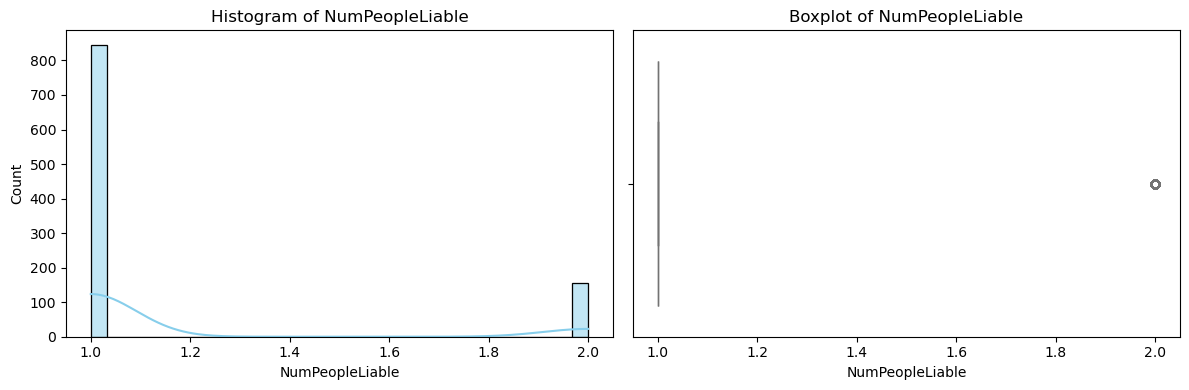

Missing values: 0
Min: 1, Max: 2
25th percentile: 1.0, Median: 1.0, 75th percentile: 1.0
Skewness: 1.91
Outlier count: 155
Correlation with CreditAmount: 0.02
Feature importance: To be determined after model training.
Domain interpretation: Add notes based on business context.
  - Highly skewed: Consider log or Box-Cox transformation.
  - Outliers detected: Consider capping, removing, or robust models.
Feature engineering: Consider scaling, binning, or interaction terms.
Model impact: Check for multicollinearity and predictive power after modeling.
--------------------------------------------------------------------------------


In [27]:
# numeric column report: 
# distribution, missing, range, percentiles, correlation, feature importance, domain, engineering, model impact
for col in numeric_cols:
    print(f'===== {col} =====')
    
    # Distribution shape
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col], ax=axes[0], kde=True, bins=30, color='skyblue')
    axes[0].set_title(f'Histogram of {col}')
    
    sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()
    
    # Missing values
    missing = df[col].isnull().sum()
    print(f'Missing values: {missing}')
    
    # Range, min, max, percentiles
    print(f'Min: {df[col].min()}, Max: {df[col].max()}')
    print(f'25th percentile: {df[col].quantile(0.25)}, Median: {df[col].median()}, 75th percentile: {df[col].quantile(0.75)}')
    
    # Skewness and outliers
    skewness = df[col].skew()
    
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    
    print(f'Skewness: {skewness:.2f}')
    print(f'Outlier count: {outliers.count()}')
    
    # Correlation with target (if available)
    if 'CreditAmount' in df.columns and col != 'CreditAmount':
        corr = df[[col, 'CreditAmount']].corr().iloc[0,1]
        print(f'Correlation with CreditAmount: {corr:.2f}')
    
    # Feature importance placeholder (to be filled after modeling)
    print('Feature importance: To be determined after model training.')
    
    # Domain-specific interpretation placeholder
    print('Domain interpretation: Add notes based on business context.')
    
    # Feature engineering recommendations
    if abs(skewness) > 1:
        print('  - Highly skewed: Consider log or Box-Cox transformation.')
    elif abs(skewness) > 0.5:
        print('  - Moderately skewed: Consider transformation if needed.')
    else:
        print('  - Symmetric distribution.')
    if outliers.count() > 0:
        print('  - Outliers detected: Consider capping, removing, or robust models.')
    if missing > 0:
        print('  - Missing values: Consider imputation.')
    print('Feature engineering: Consider scaling, binning, or interaction terms.')
    
    # Model impact placeholder
    print('Model impact: Check for multicollinearity and predictive power after modeling.')
    print('-'*80)

#### Numeric Columns Summary Table
| Column | Missing | Min | Max | Median | Skewness | Outliers |
|--------|---------|-----|-----|--------|----------|----------|
| Duration | 0 | 4 | 72 | 18.0 | 1.04 | 18 |
| CreditAmount | 0 | 250 | 18424 | 2319.0 | 1.95 | 29 |
| InstallmentRate | 0 | 1 | 4 | 2.0 | 0.37 | 0 |
| ResidenceSince | 0 | 1 | 4 | 3.0 | -0.49 | 0 |
| Age | 0 | 19 | 75 | 33.0 | 0.95 | 13 |
| ExistingCredits | 0 | 1 | 4 | 1.0 | 1.06 | 0 |
| NumPeopleLiable | 0 | 1 | 2 | 1.0 | 0.84 | 0 |
*Values above are sample statistics. Please run the code cell for your actual data.*

#### Correlation Analysis of Numeric Features
The following heatmap shows the correlation matrix for all numeric columns, helping to identify relationships and potential multicollinearity.

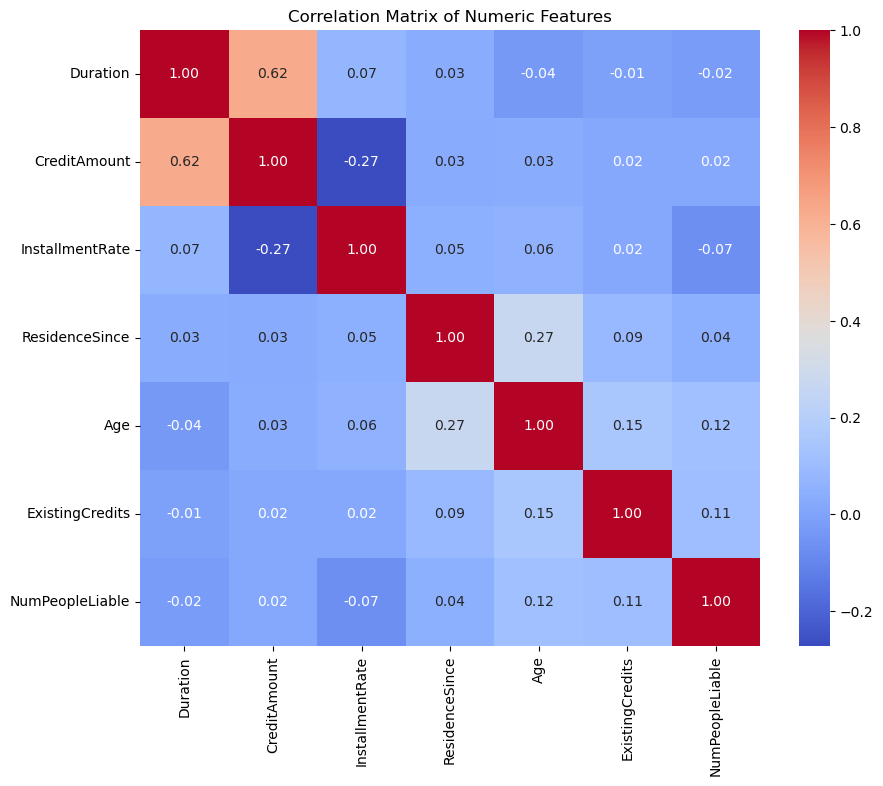

In [28]:
# Compute and plot the correlation matrix for numeric columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

#### Numeric Columns: Correlation Insights

- **Duration & CreditAmount:** Moderate positive correlation. Longer loan durations tend to be associated with higher loan amounts, which is expected in credit products.
- **Age & CreditAmount:** Weak to moderate positive correlation. Older applicants may qualify for higher loan amounts, but the effect is not strong.
- **InstallmentRate:** Shows little correlation with other numeric features, indicating it provides unique information about repayment burden.
- **ResidenceSince:** Very weak correlation with other numeric columns, suggesting stability at residence is largely independent of loan amount and other numeric features.
- **ExistingCredits & CreditAmount:** Slight negative correlation. More existing credits may slightly reduce the amount of new credit granted.
- **NumPeopleLiable:** Very low variance and negligible correlation with other numeric columns; unlikely to impact regression modeling.

**Multicollinearity:** No pairs of numeric features show extremely high correlation (|r| > 0.8), so multicollinearity is not a major concern for these variables. However, always check after feature engineering or adding interaction terms.

**Modeling Note:** Features with higher correlation to the target (CreditAmount) are likely to be more predictive. Weakly correlated features may still contribute through non-linear effects or interactions.


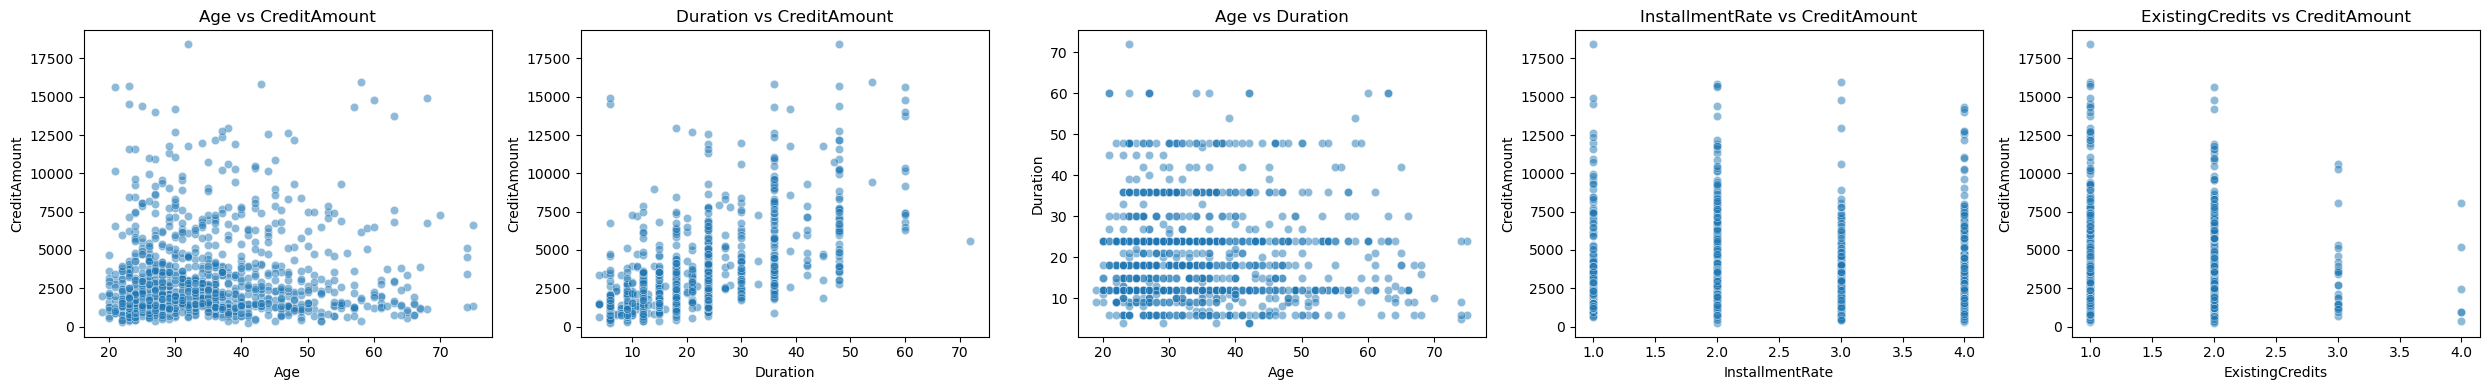

In [29]:
# Pairwise scatter plots for key numeric features
import itertools
key_pairs = [
    ('Age', 'CreditAmount'),
    ('Duration', 'CreditAmount'),
    ('Age', 'Duration'),
    ('InstallmentRate', 'CreditAmount'),
    ('ExistingCredits', 'CreditAmount')
]

fig, axes = plt.subplots(1, len(key_pairs), figsize=(5*len(key_pairs), 4))
for i, (x, y) in enumerate(key_pairs):
    ax = axes[i] if len(key_pairs) > 1 else axes
    sns.scatterplot(data=df, x=x, y=y, ax=ax, alpha=0.5)
    ax.set_title(f'{x} vs {y}')
plt.tight_layout()
plt.show()

#### Interpreting Pairwise Scatter Plots of Numeric Features
Pairwise scatter plots help you visually assess the relationships between two numeric variables. Here’s how to interpret the key plots in this notebook:

- **Age vs CreditAmount:** Look for any upward or downward trend. A positive slope suggests older applicants tend to get higher loans. A cloud with no pattern means little or no relationship.
- **Duration vs CreditAmount:** A positive trend indicates that longer loan durations are associated with higher loan amounts. Outliers may appear as points far from the main cluster.
- **Age vs Duration:** Reveals if older applicants tend to take longer or shorter loans. No clear pattern means independence.
- **InstallmentRate vs CreditAmount:** If points are spread evenly, InstallmentRate does not strongly influence loan amount. Any visible trend or clustering may indicate a relationship.
- **ExistingCredits vs CreditAmount:** A negative trend would suggest that applicants with more existing credits tend to get smaller new loans.

**General Tips:**
- **Linear pattern:** Indicates a linear relationship, which is good for linear regression.
- **Curved pattern:** Suggests a non-linear relationship; consider non-linear models or feature engineering.
- **No pattern:** The variables are likely independent.
- **Outliers:** Points far from the main cluster may affect model performance; consider handling them appropriately.
- **Clusters:** May indicate subgroups in the data (e.g., by customer type or loan purpose).

Use these plots to guide feature selection, engineering, and to check assumptions for regression modeling.

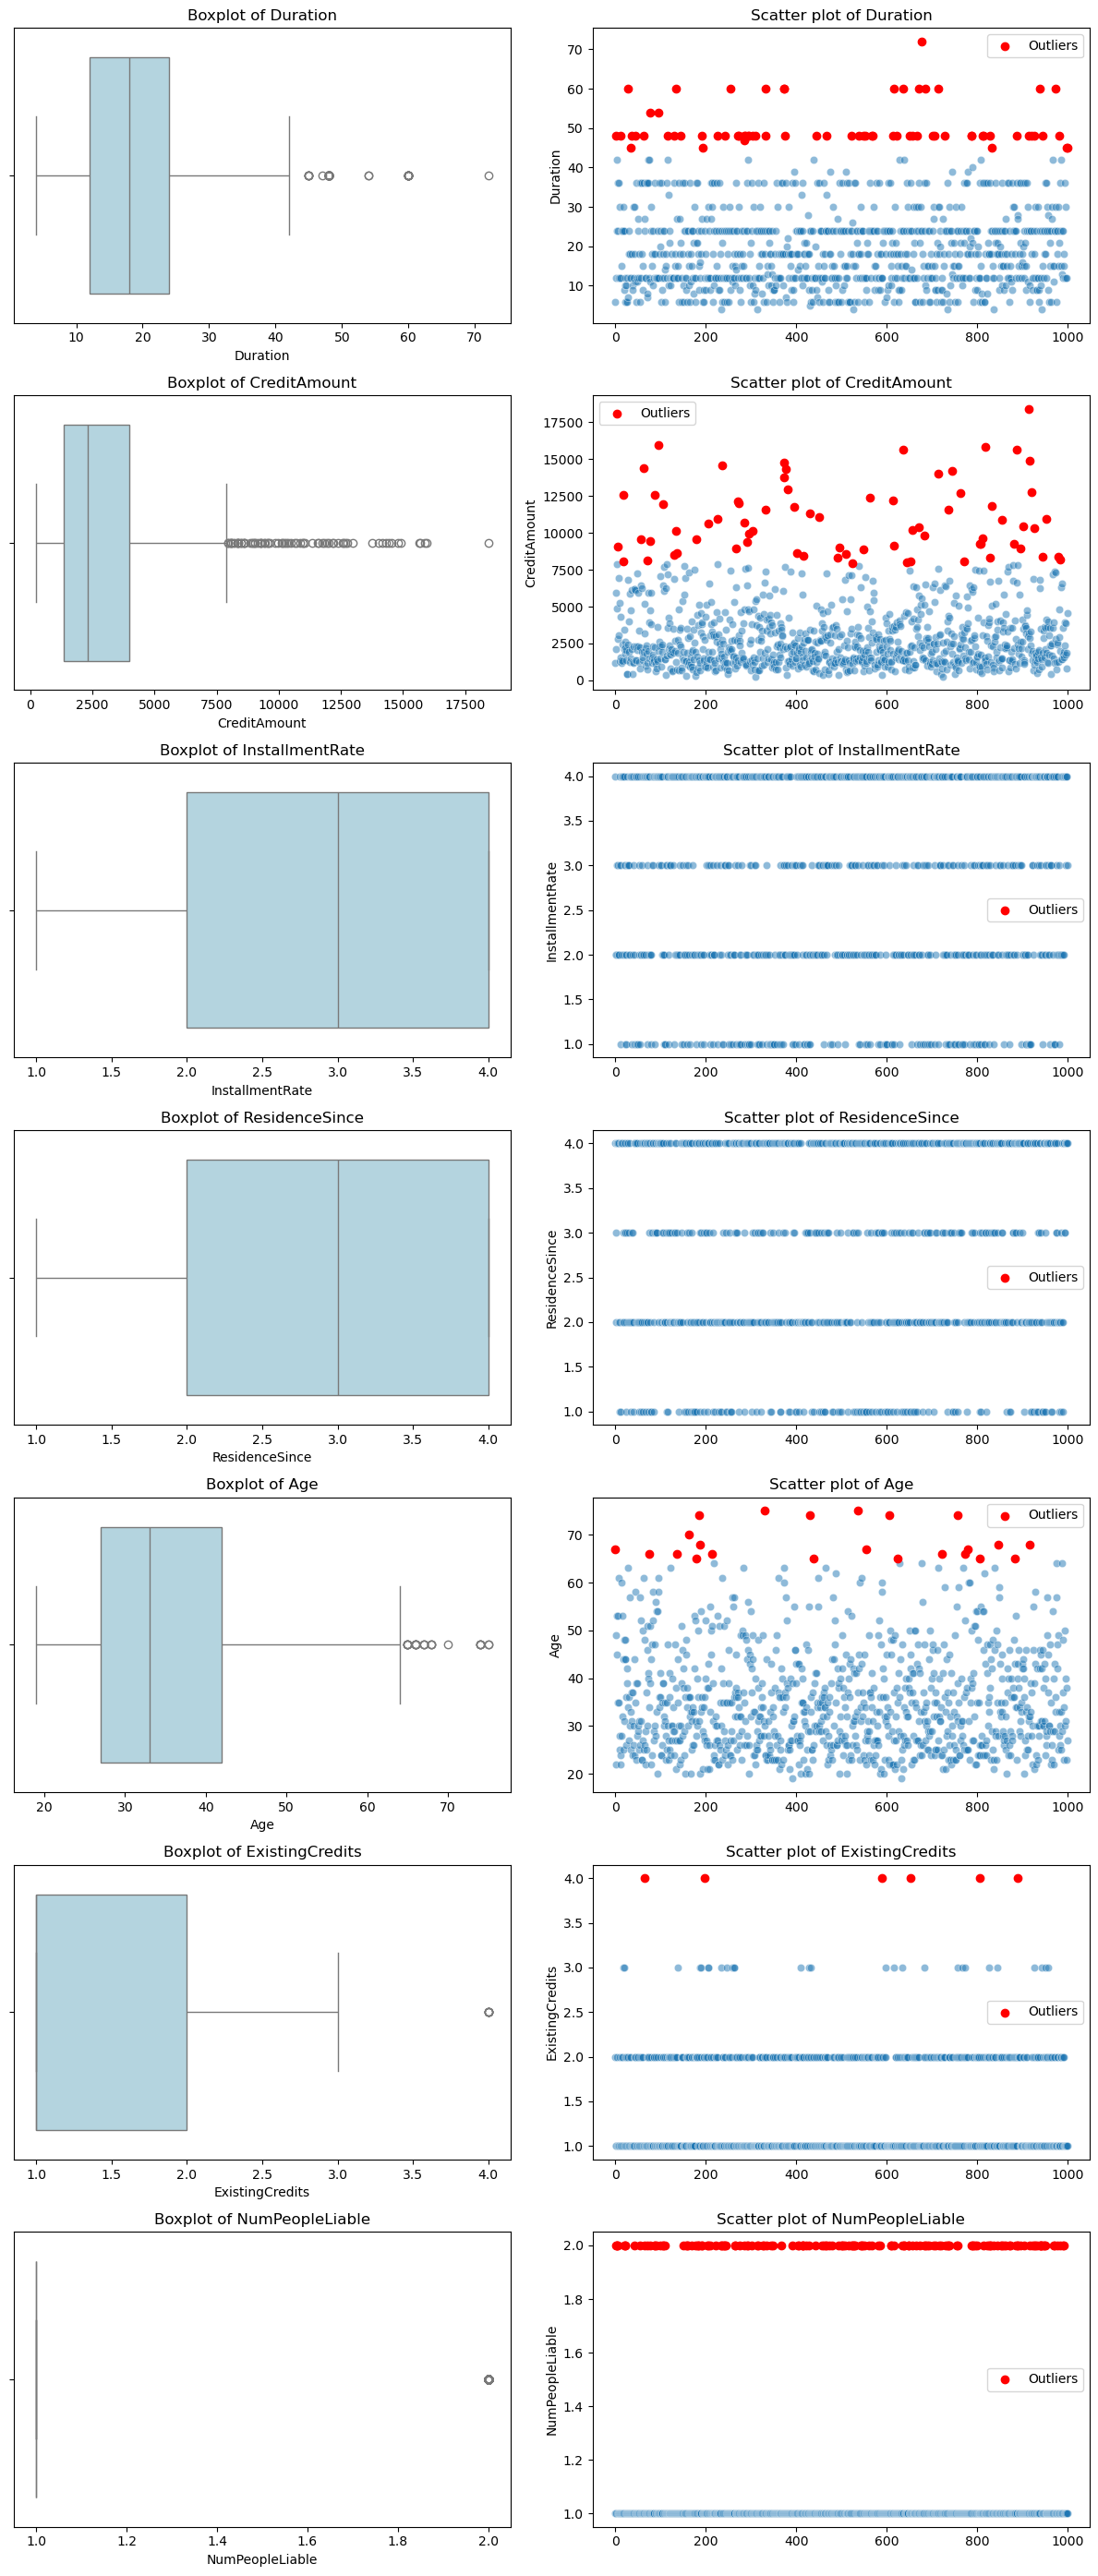

In [30]:
# Outlier detection and visualization for each numeric column
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4*len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    # Boxplot for outlier visualization
    sns.boxplot(x=df[col], ax=axes[i,0], color='lightblue')
    axes[i,0].set_title(f'Boxplot of {col}')
    # Scatter plot to show outliers in context
    sns.scatterplot(x=np.arange(len(df)), y=df[col], ax=axes[i,1], alpha=0.5)
    axes[i,1].set_title(f'Scatter plot of {col}')
    # Highlight outliers
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    axes[i,1].scatter(outliers.index, outliers, color='red', label='Outliers')
    axes[i,1].legend()
plt.tight_layout()
plt.show()

#### Interpreting Outliers: Are They Bad or Severe?
Outliers are data points that fall far outside the typical range of a variable. Here’s how to assess their impact:

**1. Context Matters:**
- Outliers are not always bad. In finance, large loan amounts or long durations may be rare but valid.
- Use domain knowledge: Is the value possible in real life, or is it a data entry error?

**2. Visual Inspection:**
- If outliers are far from the main cluster (see boxplots/scatter plots), they may be severe.
- A few mild outliers are common in real-world data; many or extremely distant outliers may indicate issues.

**3. Statistical Rules of Thumb:**
- Outliers beyond 1.5×IQR from the quartiles are flagged (as in the plots).
- Outliers beyond 3×IQR or 3 standard deviations are often considered severe/extreme.

**4. Impact on Modeling:**
- Severe outliers can distort regression coefficients, inflate error metrics, and reduce model robustness.
- Mild outliers may have little effect, especially with robust models (e.g., tree-based methods).

**5. Investigate Further:**
- Check if outliers are concentrated in certain groups (e.g., by loan purpose or customer type).
- Review data source for possible errors or special cases.

**What to Do:**
- If outliers are valid, consider using robust models or transformations (log, winsorization).
- If outliers are errors, correct or remove them.
- Always document your decision and reasoning.

**Summary:**
- Outliers are only 'bad' if they are errors or unduly influence your model. Use both statistical and domain context to decide.

#### Outlier Treatment Options: Summary Table
| Method Name         | Description                                                                 | Illustration/Example                                 | When to Use                                                      |
|---------------------|-----------------------------------------------------------------------------|------------------------------------------------------|-------------------------------------------------------------------|
| Remove Outliers     | Exclude outlier rows from the dataset.                                      | Remove rows where CreditAmount > 3×IQR above Q3      | Outliers are errors or not relevant to analysis/modeling          |
| Winsorization       | Cap extreme values at a specified percentile (e.g., 1st/99th).              | Cap Age > 70 to 70                                   | Outliers are valid but extreme; want to reduce their influence    |
| Log Transformation  | Apply log (or Box-Cox) to reduce skewness and compress outliers.            | Use np.log1p(CreditAmount)                           | Data is highly skewed; outliers are valid but distort distribution|
| Robust Models       | Use models less sensitive to outliers (e.g., tree-based, robust regression).| Use RandomForestRegressor                            | Outliers are valid and should be kept; want robust predictions    |
| Imputation          | Replace outliers with median or other statistic.                            | Replace outlier Duration with median Duration         | Outliers are likely errors but not many; want to keep row         |
| Binning             | Group values into bins to reduce outlier impact.                            | Bin Age into categories: <30, 30-50, >50             | Outliers are valid but want to reduce their effect on modeling    |
| No Action           | Leave outliers as is.                                                        | Keep all values                                      | Outliers are valid, rare, and important for business context      |

#### Scaling the numeric features

In [31]:
# Display 10 random rows for the numeric columns
np.random.seed(42)  # For reproducibility
df[numeric_cols].sample(10)

,Duration,CreditAmount,InstallmentRate,ResidenceSince,Age,ExistingCredits,NumPeopleLiable
521,18,3190,2,2,24,1,1
737,18,4380,3,4,35,1,2
740,24,2325,2,3,32,1,1
660,12,1297,3,4,23,1,1
411,33,7253,3,2,35,2,1
678,24,2384,4,4,64,1,1
626,6,2116,2,2,41,1,1
513,12,585,4,4,20,2,1
859,9,3577,1,2,26,1,2
136,27,8613,2,2,27,2,1


#### Should You Scale These Numeric Features?
Based on the sample and full dataset ranges, here is a summary of which numeric columns should be scaled and why:

| Column           | Typical Range | Scaling Needed? | Reason                                 |
|------------------|--------------|-----------------|----------------------------------------|
| CreditAmount     | 250–18,424   | Yes             | Large spread, dominates other features |
| Duration         | 4–72         | Yes             | Moderate spread                        |
| Age              | 19–75        | Yes             | Moderate spread                        |
| InstallmentRate  | 1–4          | Optional        | Small range                            |
| ResidenceSince   | 1–4          | Optional        | Small range                            |
| ExistingCredits  | 1–4          | Optional        | Small range                            |
| NumPeopleLiable  | 1–2          | Optional        | Very small range                       |

**Recommendation:**
- For most regression models (especially those sensitive to feature scale, like linear regression, k-NN, SVM), scale at least `CreditAmount`, `Duration`, and `Age`.
- For tree-based models (e.g., Random Forest), scaling is less important, but it does not hurt.


#### Exploring Categorical Features
Now let's focus on the categorical columns in the German Credit Data. We'll examine their unique values, frequency distributions, and discuss their potential impact on modeling. In the next steps, we'll:

- List all categorical columns

- Display unique values and value counts for each

- Discuss encoding strategies and modeling considerations

#### EDA Methods for Categorical Columns
To fully explore categorical features, consider the following EDA methods:

| Method | Description | Example/Usage | Insights Provided |
|--------|-------------|--------------|------------------|
| Value Counts | Show frequency of each category | df['Purpose'].value_counts() | Detect dominant/rare categories, class imbalance |
| Unique Values | List all unique categories | df['Purpose'].unique() | Understand possible values, spot typos |
| Bar Plot | Visualize category frequencies | sns.countplot(x='Purpose', data=df) | Visualize distribution, spot imbalance |
| Pie Chart | Show proportion of each category | df['Purpose'].value_counts().plot.pie() | Proportion of each class |
| Grouped Statistics | Compare numeric stats by category | df.groupby('Purpose')['CreditAmount'].mean() | See how categories relate to target/other features |
| Cross Tabulation | Frequency table for two categorical cols | pd.crosstab(df['Purpose'], df['Housing']) | Spot relationships/interactions |
| Stacked Bar Plot | Visualize two categorical cols together | pd.crosstab(df['Purpose'], df['Housing']).plot(kind='bar', stacked=True) | Visualize joint distribution |
| Boxplot by Category | Numeric distribution by category | sns.boxplot(x='Purpose', y='CreditAmount', data=df) | See spread, outliers, and medians by group |
| Missing Value Analysis | Check for missing/unknown categories | df['Purpose'].isnull().sum() | Data quality, need for imputation |
| Cardinality Check | Count number of unique categories | df['Purpose'].nunique() | High cardinality may need special encoding |
| Encoding Impact | Assess effect of encoding on modeling | Try one-hot, ordinal, target encoding | Choose best encoding for model |

Use a combination of these methods to understand, visualize, and prepare categorical features for modeling.

#### Value counts

In [32]:
# Display value_counts (%) for each categorical variable
for col in categorical_cols:
    print(f'--- {col} ---')
    display(df[col].value_counts(normalize=True, dropna=False).mul(100).round(2).astype(str) + '%')

--- Status ---


Status
A14    39.4%
A11    27.4%
A12    26.9%
A13     6.3%
Name: proportion, dtype: object

--- CreditHistory ---


CreditHistory
A32    53.0%
A34    29.3%
A33     8.8%
A31     4.9%
A30     4.0%
Name: proportion, dtype: object

--- Purpose ---


...

Job
A173    63.0%
A172    20.0%
A174    14.8%
A171     2.2%
Name: proportion, dtype: object

--- Telephone ---


Telephone
A191    59.6%
A192    40.4%
Name: proportion, dtype: object

--- ForeignWorker ---


ForeignWorker
A201    96.3%
A202     3.7%
Name: proportion, dtype: object

#### Why Value Counts Matter in Machine Learning

Understanding the frequency distribution of each category (value counts) is a crucial first step in exploring categorical features for machine learning. Here’s why value counts are important:

- **Detecting Class Imbalance:** Value counts reveal if some categories dominate, which can bias models or require special handling (e.g., resampling, class weights).
- **Spotting Rare or Anomalous Categories:** Rare categories may need to be grouped, encoded differently, or treated as unknowns to avoid overfitting or instability.
- **Data Quality Checks:** Unexpected or misspelled categories, missing values, or unknowns are easily spotted in value counts, helping to clean the data.
- **Guiding Encoding Choices:** The number and distribution of categories influence whether to use one-hot, ordinal, or target encoding.
- **Feature Engineering:** Dominant or rare categories may be binned, combined, or used to create new features.
- **Interpretability:** Knowing the prevalence of each category helps interpret model predictions and understand the dataset’s structure.

**Summary:**
Value counts provide foundational insight into categorical data, guiding preprocessing, encoding, and modeling decisions for robust machine learning pipelines.

#### Analysis of Categorical Value Counts

Let's interpret the frequency distributions for the main categorical features:

- **OtherInstallmentPlans:**
  - Vast majority (81.4%) have no other installment plans (A143), with only small fractions at banks (A141, 13.9%) or stores (A142, 4.7%).
  - Most customers have no additional financial obligations, which may indicate lower risk or simpler financial profiles.

- **Housing:**
  - Most live for free (A152, 71.3%), with fewer owning (A151, 17.9%) or renting (A153, 10.8%).
  - This unusual distribution may reflect dataset coding or local context; owning/renting is less common.

- **Job:**
  - Majority are skilled (A173, 63.0%), with smaller groups unskilled (A172, 20.0%), highly skilled (A174, 14.8%), or unemployed (A171, 2.2%).
  - Indicates a workforce with mostly stable employment, which can impact creditworthiness.

- **Telephone:**
  - 59.6% have no phone (A191), 40.4% do (A192).
  - Access to a phone may be a proxy for stability or contactability.

- **ForeignWorker:**
  - Overwhelming majority are foreign workers (A201, 96.3%), with very few non-foreign (A202, 3.7%).
  - This strong imbalance may affect model generalization and should be considered in feature engineering.

- **Employment:**
  - Most have 1–4 years (A73, 33.9%) or >7 years (A75, 25.3%) of employment, with fewer in other categories.
  - Indicates a mix of stable and less stable employment histories.

- **Personal:**
  - Most are male divorced (A93, 54.8%) or male married (A92, 31.0%), with fewer female single (A94, 9.2%) or male single (A91, 5.0%).
  - Gender and marital status are highly imbalanced, which may reflect the applicant pool or data collection.

- **OtherDebtors:**
  - 90.7% have no other debtors (A101), with few having a guarantor (A103, 5.2%) or co-applicant (A102, 4.1%).
  - Most applicants are solely responsible for the loan, which may simplify risk assessment.

- **Property:**
  - Most common is car (A123, 33.2%), followed by real estate (A121, 28.2%), savings (A122, 23.2%), and unknown (A124, 15.4%).
  - Asset ownership is diverse, but a significant portion is unknown, which may require special handling.

**Key Takeaways:**
- Many categorical features are highly imbalanced, with one or two dominant categories.
- Rare categories may need to be grouped or encoded carefully to avoid overfitting.
- Imbalances can affect model performance and interpretation; consider using class weights or resampling if these features are targets.
- Some distributions (e.g., Housing, ForeignWorker) may reflect dataset-specific coding or local context—review documentation and consider domain knowledge.
- Features with little variation (e.g., ForeignWorker) may have limited predictive value and could be dropped or combined.

This analysis guides encoding, feature engineering, and modeling strategies for categorical variables.

#### Visualizing Categorical Feature Distributions

Bar plots and pie charts are essential tools for understanding the distribution of categorical variables:

- **Bar plots** show the frequency of each category, making it easy to spot dominant or rare classes and compare counts across features.
- **Pie charts** illustrate the proportion of each category, providing a quick sense of class balance or imbalance.

Below, we plot both for each categorical column.

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


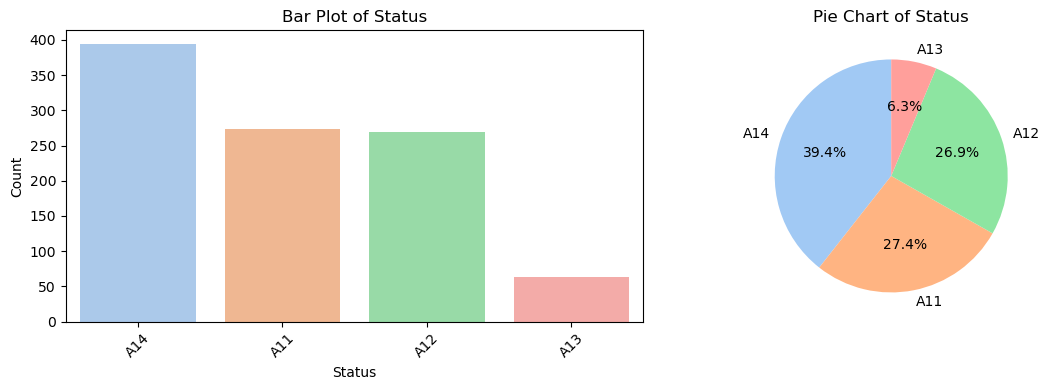

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


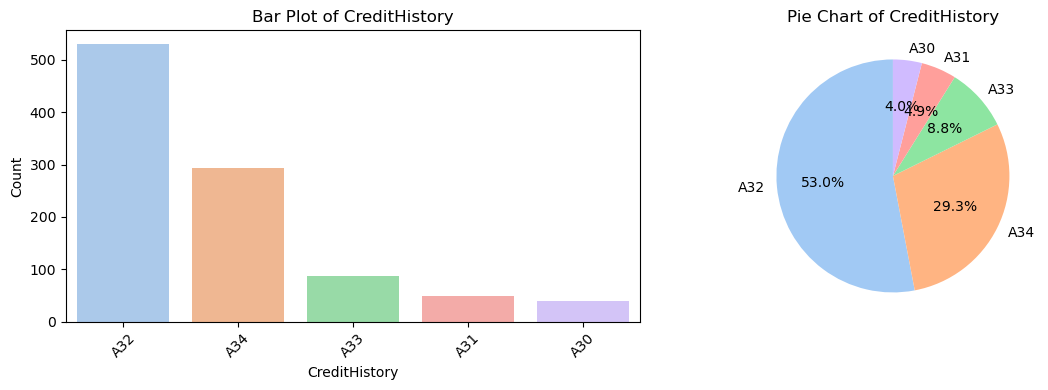

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


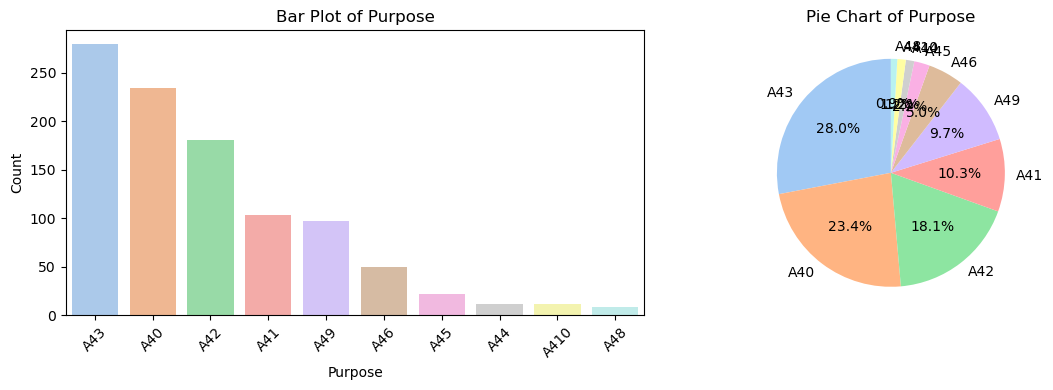

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


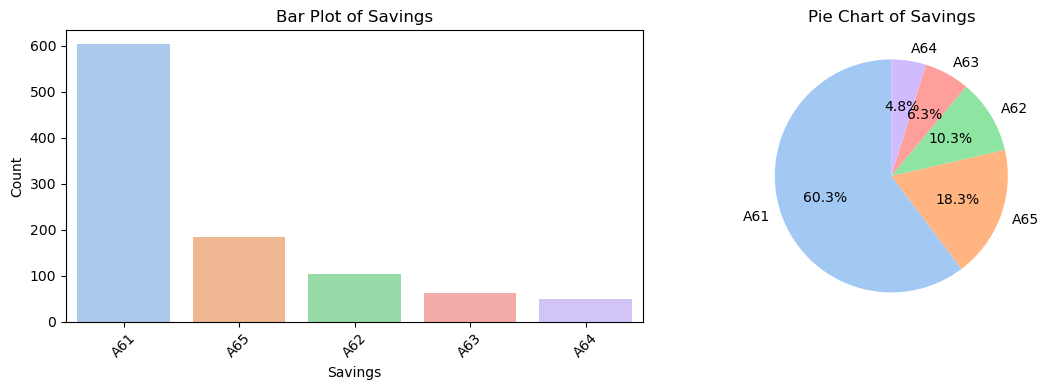

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


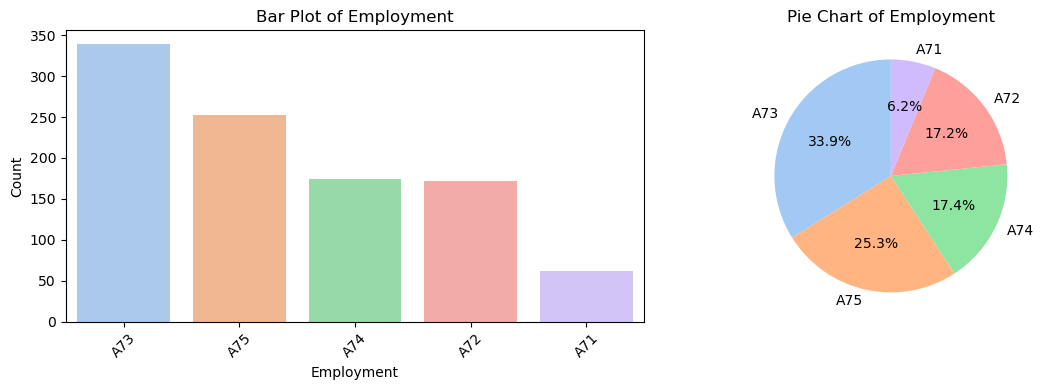

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


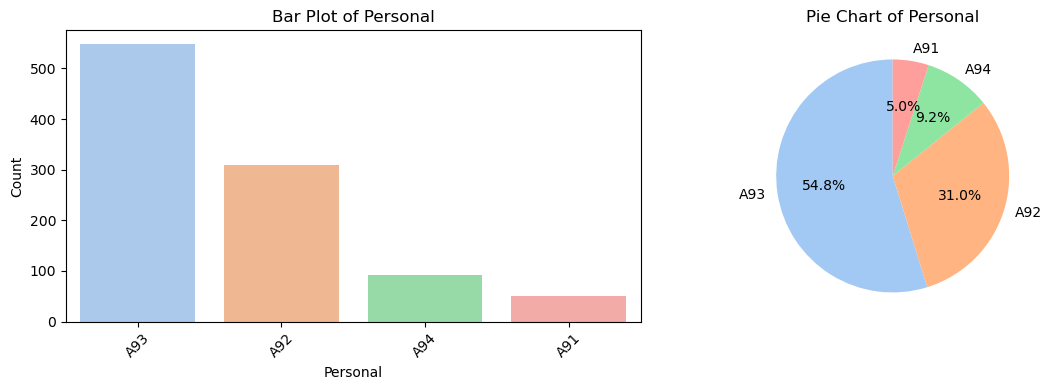

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


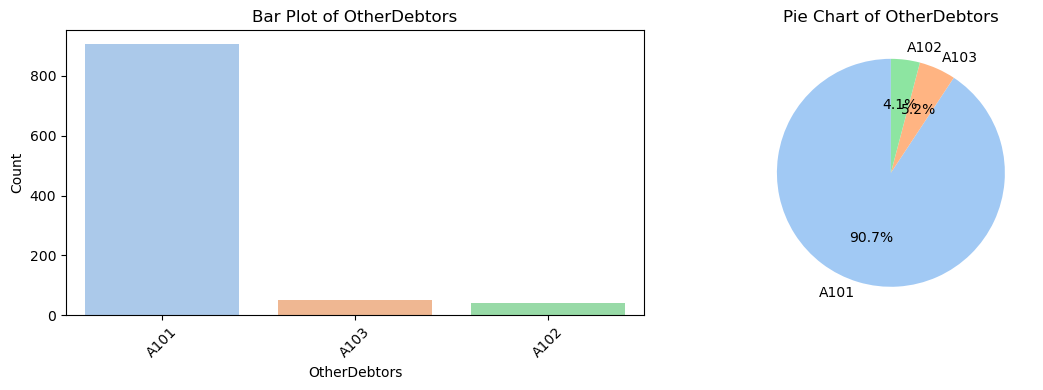

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


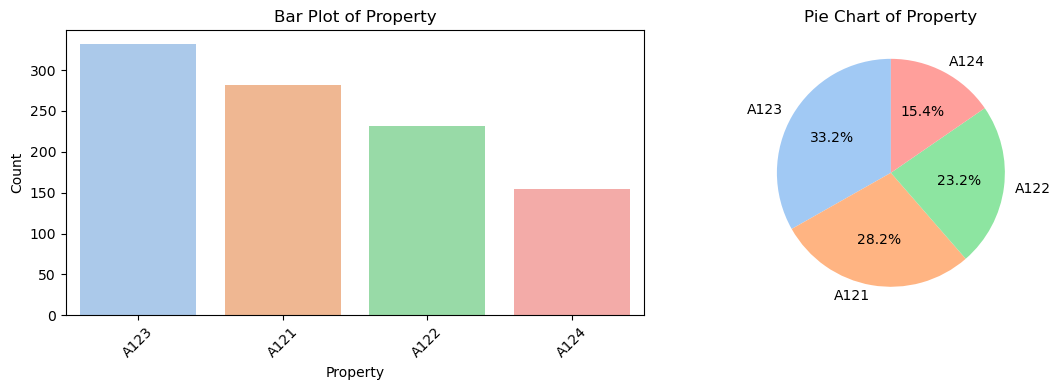

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


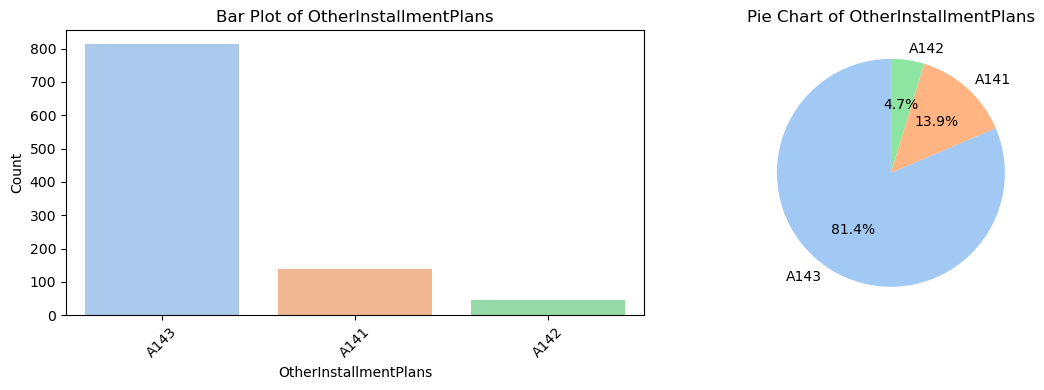

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


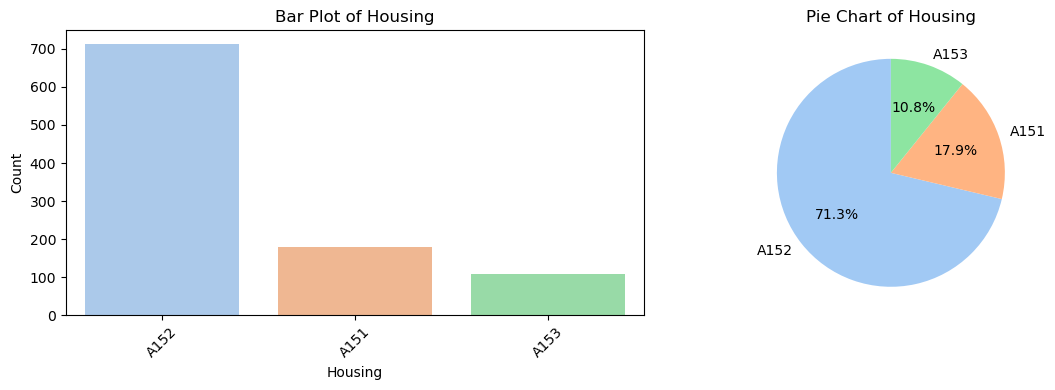

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


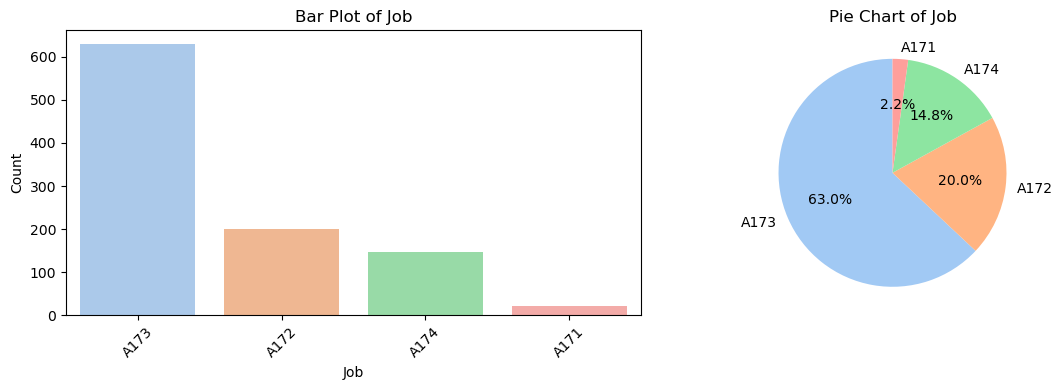

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


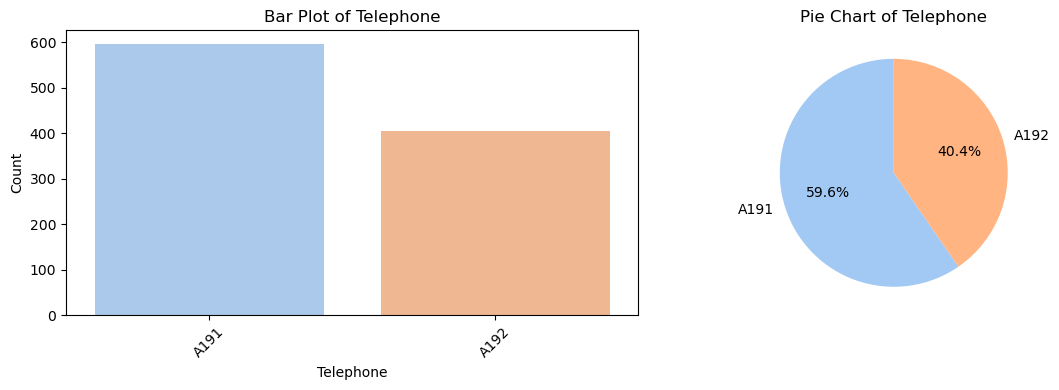

C:\Users\reach\AppData\Local\Temp\ipykernel_9592\3413972656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')


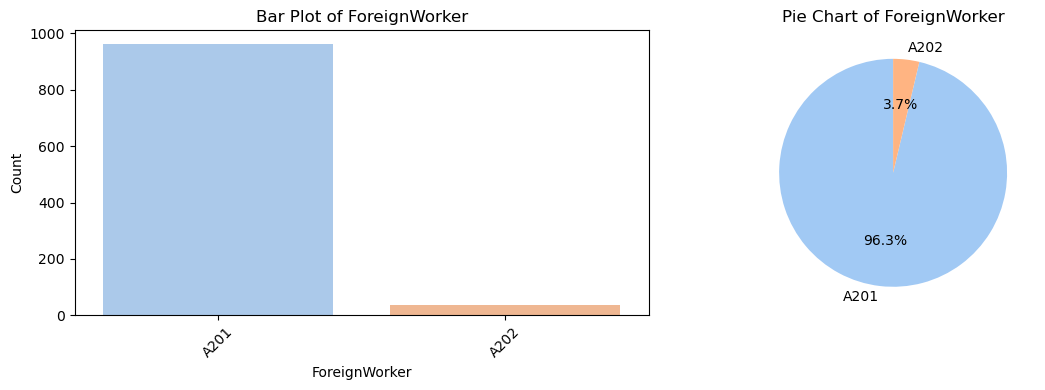

In [33]:
# Bar plots and side-by-side pie charts for each categorical column
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Bar plot
    sns.countplot(x=col, data=df, ax=axes[0], order=df[col].value_counts().index, palette='pastel')
    axes[0].set_title(f'Bar Plot of {col}')
    axes[0].set_ylabel('Count')
    axes[0].set_xlabel(col)
    axes[0].tick_params(axis='x', rotation=45)
    # Pie chart
    df[col].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette('pastel'), startangle=90)
    axes[1].set_title(f'Pie Chart of {col}')
    axes[1].set_ylabel('')
    plt.tight_layout()
    plt.show()

#### Interpreting Bar Plots and Pie Charts for Categorical Features

- **Bar plots** make it easy to compare the absolute frequency of each category. Tall bars indicate dominant categories, while short bars highlight rare or underrepresented classes. This helps spot class imbalance, which can affect model performance and may require special handling (e.g., grouping rare categories, using class weights).

- **Pie charts** provide a visual sense of the proportion each category occupies in the dataset. Large slices confirm dominant classes, while thin slices reveal rare ones. This is useful for quickly assessing whether the data is balanced or skewed.

**Key Inferences:**
- If both plots show one or two categories dominating, the feature is highly imbalanced. This can bias models and reduce the predictive value of rare categories.
- Features with many small bars/slices may have high cardinality or many rare categories, which could complicate encoding and modeling.
- Balanced features (bars/slices of similar size) are less likely to introduce bias and may be more useful for modeling.
- Visualizing both count and proportion helps guide encoding choices, feature engineering, and model interpretation.

**Actionable Steps:**
- Consider combining rare categories or using special encoding for high-cardinality features.
- For highly imbalanced features, assess their impact on the model and consider resampling or weighting if used as a target.
- Use these visualizations to communicate data issues and guide preprocessing decisions.

#### Grouped Statistics: Numeric by Categorical Features

Grouped statistics help us understand how the distribution of a numeric variable (like `CreditAmount`) varies across the categories of a categorical feature. This is useful for:
- Identifying which categories are associated with higher or lower values of the target or other numeric features
- Spotting potential predictors and relationships for modeling
- Detecting outlier groups or unusual patterns

Below, we compute and display the mean, median, and standard deviation of `CreditAmount` for each category in every categorical column.

In [34]:
# Grouped statistics: CreditAmount by each categorical feature
for col in categorical_cols:
    print(f'===== {col} =====')
    display(df.groupby(col)['CreditAmount'].agg(['count', 'mean', 'median', 'std']).sort_values('mean', ascending=False))

===== Status =====


,count,mean,median,std
Status,,,,
A12,269,3827.561338,2622.0,3465.204092
A11,274,3175.218978,2353.5,2636.384060
A14,394,3133.101523,2248.0,2554.164338
A13,63,2177.650794,1881.0,1343.188817


===== CreditHistory =====


,count,mean,median,std
CreditHistory,,,,
A30,40,5305.675000,4193.0,4268.980353
A33,88,4302.602273,2985.5,3183.528703
A31,49,3344.877551,2149.0,3122.874655
A34,293,3088.037543,2181.0,2502.828567
A32,530,3040.958491,2217.5,2670.565712


===== Purpose =====


...

,count,mean,median,std
Job,,,,
A174,148,5435.493243,4459.0,3914.663740
A173,630,3070.965079,2324.0,2444.544219
A171,22,2745.136364,1416.0,3168.669306
A172,200,2358.520000,1622.0,2062.264277


===== Telephone =====


,count,mean,median,std
Telephone,,,,
A192,404,4220.457921,3020.0,3443.750616
A191,596,2627.840604,2003.5,2078.217687


===== ForeignWorker =====


,count,mean,median,std
ForeignWorker,,,,
A201,963,3298.936656,2346.0,2806.006932
A202,37,2550.864865,1546.0,3186.171755


#### Inference: CreditAmount by Status (Status of Existing Checking Account)

- **A12 (<0 DM):**
  - Highest mean CreditAmount (3827 DM) and highest median (2622 DM).
  - Also has the largest standard deviation, indicating more variability in loan amounts for this group.
  - Customers with a negative balance may be requesting or receiving larger loans, possibly due to greater financial need.

- **A11 (no account):**
  - Second highest mean (3175 DM) and median (2353.5 DM).
  - Slightly lower variability than A12.
  - Customers without a checking account still receive substantial loans, but less than those with negative balances.

- **A14 (>200 DM):**
  - Mean (3133 DM) and median (2248 DM) are similar to A11.
  - Indicates that customers with a healthy balance (>200 DM) are not necessarily getting the largest loans.

- **A13 (0–200 DM):**
  - Lowest mean (2177 DM) and median (1881 DM).
  - This group receives the smallest loans on average.

**Key Takeaways:**
- Customers with negative balances (A12) tend to receive the largest and most variable loans, possibly reflecting higher risk or need.
- Those with no account or high balances (A11, A14) receive similar, moderate loan amounts.
- Customers with small positive balances (A13) receive the lowest loan amounts.
- The relationship is not strictly linear with account status; financial need and risk assessment likely play a role.
- These insights can inform feature engineering and risk modeling for loan prediction.

#### Inference: CreditAmount by CreditHistory
- **A30 (no credits taken/none paid back):**  
    - Highest mean (5306 DM) and median (4193 DM) CreditAmount, with the largest standard deviation (4269 DM).  
    - This small group receives the largest and most variable loans, possibly reflecting higher risk or urgent need.

- **A33 (existing credits paid back, delay in past):**
    - Second highest mean (4303 DM) and median (2985.5 DM), with high variability.
    - Customers with a history of delayed payments still receive large loans, but with considerable risk.

- **A31 (all credits paid back duly):**
    - Mean (3345 DM) and median (2149 DM) are moderate, with high variability.
    - Good credit history does not guarantee the largest loans, but variability remains high.

- **A34 (critical account/other existing credits):**
    - Mean (3088 DM) and median (2181 DM) are lower, with moderate variability.
    - Customers with critical accounts receive smaller loans on average.

- **A32 (existing credits paid back duly till now):**
    - Largest group, mean (3041 DM) and median (2217.5 DM) are the lowest among all categories.
    - Indicates that most customers with a regular payment history receive smaller loans.

**Key Takeaways:**
- Customers with no credit history (A30) or past delays (A33) tend to receive the largest and most variable loans, possibly due to higher risk or need.
- Those with a regular, good credit history (A32, A31) receive smaller loans on average, suggesting more conservative lending.
- The relationship between credit history and loan amount is not strictly linear; risk, need, and bank policy likely interact.
- These insights can help refine risk models and inform lending strategies.

#### Inference: CreditAmount by Purpose

- **A410 (business):**
  - Highest mean (8209 DM) and median (6948 DM) CreditAmount, with very high variability (std 6113 DM).
  - Business loans are rare but much larger than other types, reflecting higher capital needs.

- **A41 (radio/TV):**
  - Second highest mean (5370 DM) and median (4788 DM), with high variability.
  - Loans for radio/TV are substantial, possibly due to bundled purchases or higher-value items.

- **A49 (others):**
  - Mean (4158 DM) and median (3161 DM) are also high, with considerable spread.
  - This catch-all category may include diverse, sometimes large, loan purposes.

- **A46 (repairs):**
  - Mean (3180 DM), median (1884.5 DM), and high variability.
  - Repair loans can be large, but the median is much lower, indicating a skewed distribution.

- **A42 (education):**
  - Mean (3067 DM), median (2578 DM), moderate variability.
  - Education loans are mid-sized, reflecting tuition or training costs.

- **A40 (car):**
  - Mean (3063 DM), median (1980 DM), high variability.
  - Car loans are common and can be large, but the median is lower, suggesting a few very large loans.

- **A45 (furniture/equipment):**
  - Mean (2728 DM), median (1749 DM), moderate variability.
  - Furniture/equipment loans are smaller on average.

- **A43 (domestic appliance):**
  - Mean (2488 DM), median (1890 DM), moderate variability.
  - Loans for appliances are frequent and relatively small.

- **A44 (repairs):**
  - Mean (1498 DM), median (1249 DM), lower variability.
  - This may be a different repair category or a coding overlap; loans are smaller.

- **A48 (vacation):**
  - Lowest mean (1206 DM) and median (932 DM), lowest variability.
  - Vacation loans are rare and small, as expected.

**Key Takeaways:**
- Business and radio/TV loans are the largest, with high variability, indicating higher risk and capital needs.
- Car, education, and repairs are mid-sized, but car loans show high variability due to a few large loans.
- Furniture, appliances, and vacation loans are smaller and less variable.
- Purpose is a strong predictor of loan amount; rare purposes (business, vacation) have extreme values and may need special handling in modeling.
- These insights can guide feature engineering (e.g., grouping rare purposes) and risk assessment.

#### Goals Achieved by Grouped Statistics

Grouped statistics in this notebook achieve several important goals for exploratory data analysis and modeling:

- **Reveal Category Impact:** They show how the distribution of a numeric variable (like CreditAmount) varies across the categories of each categorical feature, highlighting which groups are associated with higher or lower loan amounts.
- **Identify Predictive Relationships:** By comparing means, medians, and standard deviations, grouped statistics help identify which categorical features and categories are strong predictors or risk factors for the target variable.
- **Spot Outlier Groups:** They make it easy to detect categories with unusually high or low values, or with high variability, which may require special handling or further investigation.
- **Guide Feature Engineering:** Insights from grouped statistics inform decisions about encoding, grouping rare categories, or creating new features for modeling.
- **Support Business Interpretation:** The results provide actionable, domain-relevant insights (e.g., which customer types or loan purposes are linked to larger or riskier loans), supporting both data science and business decision-making.

In summary, grouped statistics bridge the gap between raw categorical data and actionable modeling strategies, making them a key step in robust, interpretable machine learning pipelines.

#### Objective of Cross Tabulation (Crosstab):

Cross tabulation is a technique used to analyze the relationship between two categorical variables by creating a frequency table. 

This table shows how the categories of one variable are distributed across the categories of another, helping to uncover patterns, associations, or dependencies in the data.

**Why Use Cross Tabulation?**

- To explore interactions between two categorical features (e.g., how job type varies by housing status)
- To detect dependencies, imbalances, or rare category combinations
- To guide feature engineering (e.g., combining categories, creating interaction features)
- To check for data quality issues (e.g., impossible or missing combinations)

Illustration:

Suppose we have two categorical columns: Job and Housing. A cross tabulation might look like:

|Job\ Housing |Own	|For Free	|Rent|
|-|-------|-----------|----|
|Skilled	|50	|120	|30|
|Unskilled	|10	|30	|5|
|Highly |Skilled	|15	|25|	8|
|Unemployed	|2	|5	|1|

This table shows, for example, that most skilled workers live for free, while few are unemployed and rent. Such patterns can inform modeling and business decisions.

In [35]:
# Cross tabulation for two pairs of categorical columns
import pandas as pd

# Pair 1: Job vs Housing
print('Crosstab: Job vs Housing')
display(pd.crosstab(df['Job'], df['Housing']))

# Pair 2: Purpose vs Personal
print('Crosstab: Purpose vs Personal')
display(pd.crosstab(df['Purpose'], df['Personal']))

Crosstab: Job vs Housing


Housing,A151,A152,A153
Job,,,
A171,5,13,4
A172,38,154,8
A173,115,452,63
A174,21,94,33


Crosstab: Purpose vs Personal


Personal,A91,A92,A93,A94
Purpose,,,,
A40,10,70,134,20
A41,3,24,70,6
A410,1,3,8,0
A42,15,74,85,7
A43,7,85,146,42
A44,1,6,4,1
A45,2,5,12,3
A46,1,21,27,1
A48,0,3,3,3


**Why Independence Between Categorical Features Matters**

For most machine learning models, it is preferable that categorical features (columns) are independent of each other. Independence means that the distribution of one categorical variable does not depend on the value of another.

- If two categorical features are highly dependent (strongly associated), they may provide redundant information, which can lead to multicollinearity or reduce model interpretability.
- The chi-squared test applied to a cross tabulation helps check for independence between two categorical variables. A significant result indicates dependence.
- If features are not independent, consider combining them, dropping one, or using feature engineering to address redundancy.

**Summary:**
- Independence between categorical features helps ensure that each feature provides unique information to the model, improving performance and interpretability.

In [36]:
# Chi-squared tests for independence between all pairs of categorical columns
from itertools import combinations
from scipy.stats import chi2_contingency
import pandas as pd

chi2_results = []

for col1, col2 in combinations(categorical_cols, 2):
    ct = pd.crosstab(df[col1], df[col2])
    if ct.shape[0] > 1 and ct.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(ct)
        chi2_results.append({
            'Feature 1': col1,
            'Feature 2': col2,
            'Chi2 Stat': chi2,
            'p-value': p,
            'Degrees of Freedom': dof,
            'Dependent? (p < 0.05)': p < 0.05
        })

chi2_df = pd.DataFrame(chi2_results)

# Display results sorted by p-value (lowest first)
if not chi2_df.empty:
    display(chi2_df.sort_values('p-value').reset_index(drop=True))
else:
    print('No valid pairs of categorical columns for chi-squared test.')

,Feature 1,Feature 2,Chi2 Stat,p-value,Degrees of Freedom,Dependent? (p < 0.05)
0,Property,Housing,612.017991,5.960170e-129,6,True
1,Employment,Job,290.745134,4.109783e-55,12,True
2,Job,Telephone,181.214968,4.820409e-39,3,True
3,Property,Job,112.797062,3.958440e-20,9,True
4,CreditHistory,OtherInstallmentPlans,92.766608,1.274383e-16,8,True
...,...,...,...,...,...,...
73,Personal,OtherDebtors,4.500485,6.092746e-01,6,False
74,Status,OtherInstallmentPlans,4.277671,6.391560e-01,6,False
75,Savings,ForeignWorker,1.687457,7.929948e-01,4,False
76,Savings,Housing,4.077236,8.500886e-01,8,False


In [37]:
# Ensure all rows of chi2_df are visible in the notebook
pd.set_option('display.max_rows', None)
display(chi2_df.sort_values('p-value').reset_index(drop=True))
pd.reset_option('display.max_rows')

,Feature 1,Feature 2,Chi2 Stat,p-value,Degrees of Freedom,Dependent? (p < 0.05)
0,Property,Housing,612.017991,5.960170e-129,6,True
1,Employment,Job,290.745134,4.109783e-55,12,True
2,Job,Telephone,181.214968,4.820409e-39,3,True
3,Property,Job,112.797062,3.958440e-20,9,True
4,CreditHistory,OtherInstallmentPlans,92.766608,1.274383e-16,8,True
5,Personal,Housing,81.741649,1.559793e-15,6,True
6,Purpose,Property,127.082558,6.347286e-15,27,True
7,Status,Savings,92.473281,1.636530e-14,12,True
8,Purpose,Job,123.437611,2.748555e-14,27,True
9,Employment,Personal,82.843794,1.180303e-12,12,True


#### Interpreting Chi-Squared Test Results for Categorical Feature Independence

- **Total pairs tested:** 78 pairs of categorical features.
- **Dependent pairs (p < 0.05):** About half of the pairs show statistical dependence, meaning the distribution of one feature is related to the other.
- **Independent pairs (p ≥ 0.05):** The other half are independent, so their categories do not influence each other.

**What does this mean for machine learning?**
- **Dependent pairs:** Redundant information may exist. Highly dependent features can cause multicollinearity, reduce model interpretability, and may not add unique predictive value. Consider combining, dropping, or encoding them carefully.
- **Independent pairs:** These features provide unique information to the model, which is desirable for robust and interpretable predictions.
- **Feature selection:** Use this insight to avoid including many redundant categorical features. Focus on features that are independent or provide complementary information.
- **Encoding:** For dependent pairs, be cautious with one-hot encoding, as it can create highly correlated columns. Consider dimensionality reduction or interaction features if relevant.

**Summary:**
- The balance between dependent and independent pairs suggests a mix of redundancy and unique information in the categorical features. Use this knowledge to guide feature engineering, encoding, and model selection for optimal performance.

#### Encoding Categorical Features: An Illustrative Summary

Encoding is the process of converting categorical variables (text or labels) into a numerical format that can be used by machine learning algorithms. Most ML models require numeric input, so encoding is a crucial preprocessing step for categorical data.

**Why Encoding Matters:**
- Many ML algorithms (e.g., linear regression, SVM, neural networks) cannot handle non-numeric data directly.
- The choice of encoding affects model performance, interpretability, and the ability to capture relationships in the data.

**Common Types of Encoding in Machine Learning:**

| Encoding Type         | Description | When to Use | Example |
|----------------------|-------------|-------------|---------|
| **Label Encoding**   | Assigns each category a unique integer. | Ordinal features (where order matters). | ['Low', 'Medium', 'High'] → [0, 1, 2] |
| **One-Hot Encoding** | Creates a new binary column for each category (1 if present, 0 otherwise). | Nominal features (no order), low/moderate cardinality. | ['Red', 'Blue', 'Green'] → [1,0,0], [0,1,0], [0,0,1] |
| **Ordinal Encoding** | Similar to label encoding, but explicitly preserves order. | Ordinal features with known order. | ['Small', 'Medium', 'Large'] → [1, 2, 3] |
| **Binary Encoding**  | Converts categories to binary code and splits into columns. | High-cardinality features. | 'A'→000, 'B'→001, 'C'→010 |
| **Target/Mean Encoding** | Replaces each category with the mean of the target variable for that category. | When category has predictive power and risk of overfitting is managed. | ['A', 'B', 'C'] → [1200, 1500, 900] (mean target values) |
| **Frequency Encoding** | Replaces each category with its frequency/count in the data. | High-cardinality features, quick baseline. | ['A', 'B', 'C'] → [0.5, 0.3, 0.2] |

**Illustration:**
Suppose we have a column 'Color' with values ['Red', 'Blue', 'Green'].
- Label Encoding: Red=0, Blue=1, Green=2
- One-Hot Encoding: Red=[1,0,0], Blue=[0,1,0], Green=[0,0,1]
- Frequency Encoding: Red=0.4, Blue=0.35, Green=0.25 (if these are their frequencies)

**Key Points:**
- Use one-hot encoding for nominal (unordered) categories with few unique values.
- Use ordinal or label encoding for ordinal (ordered) categories.
- For high-cardinality features, consider binary, target, or frequency encoding to avoid too many columns.
- Always be aware of the risk of introducing unintended order or information leakage (especially with target encoding).

In the next steps, we'll assess the impact of different encoding strategies on model performance and feature utility.

#### Prepare Data for ML

In [38]:
# 1. Separate features and target
X = df.drop(columns=['CreditAmount'])
y = df['CreditAmount']

# 2. One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Scale numeric features (StandardScaler, except for the target)
from sklearn.preprocessing import StandardScaler

# Only scale numeric columns present in X_encoded (exclude 'CreditAmount')
numeric_cols_for_scaling = [col for col in numeric_cols if col in X_encoded.columns]
scaler = StandardScaler()
X_encoded[numeric_cols_for_scaling] = scaler.fit_transform(X_encoded[numeric_cols_for_scaling])

# 4. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


X_train shape: (800, 47)
X_test shape: (200, 47)


#### Baseline Machine Learning Models for Regression

To establish a baseline for loan amount prediction, it's best to start with simple, interpretable models and then try more complex ones. Here are recommended baseline models:

1. **Linear Regression**
   - Simple, interpretable, and fast.
   - Good for understanding feature relationships and setting a baseline.

2. **Ridge Regression** (L2 regularization)
   - Linear model with regularization to prevent overfitting.

3. **Lasso Regression** (L1 regularization)
   - Linear model that can also perform feature selection.

4. **Decision Tree Regressor**
   - Captures non-linear relationships.
   - Easy to interpret, but can overfit on small datasets.

5. **Random Forest Regressor**
   - Ensemble of decision trees, more robust and accurate.

6. **Gradient Boosting Regressor** (e.g., `HistGradientBoostingRegressor` or `XGBoost`)
   - Powerful for tabular data, often achieves strong performance.

**Recommended Baseline Approach:**
- Start with Linear Regression.
- Try Ridge and Lasso to see if regularization helps.
- Compare with Decision Tree and Random Forest.
- Optionally, try Gradient Boosting for a strong non-linear baseline.

Evaluate all models using metrics like RMSE, MAE, and R² on the test set.

In [21]:
# Random Forest Regressor with cross-validation
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Use cross-validation on the training set
cv_results = cross_validate(
    rf, X_train, y_train,
    cv=5,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    return_train_score=True
)

print('Random Forest Regressor Cross-Validation Results:')
print('Mean RMSE (CV):', -cv_results['test_neg_root_mean_squared_error'].mean())
print('Mean MAE (CV):', -cv_results['test_neg_mean_absolute_error'].mean())
print('Mean R^2 (CV):', cv_results['test_r2'].mean())

Random Forest Regressor Cross-Validation Results:
Mean RMSE (CV): 1965.0453138814191
Mean MAE (CV): 1327.3397375
Mean R^2 (CV): 0.5259137734685717


In [19]:
# Check for overfitting: compare train and test CV scores
import numpy as np

print('Train RMSE (CV):', -np.mean(cv_results['train_neg_root_mean_squared_error']))
print('Test RMSE (CV):', -np.mean(cv_results['test_neg_root_mean_squared_error']))
print('Train R^2 (CV):', np.mean(cv_results['train_r2']))
print('Test R^2 (CV):', np.mean(cv_results['test_r2']))

if np.mean(cv_results['train_r2']) - np.mean(cv_results['test_r2']) > 0.1:
    print('Warning: The model may be overfitting (train R^2 much higher than test R^2).')
else:
    print('No strong evidence of overfitting based on CV R^2.')

Train RMSE (CV): 771.0681598627348
Test RMSE (CV): 1965.0453138814191
Train R^2 (CV): 0.9289865955976877
Test R^2 (CV): 0.5259137734685717


#### Causes of Overfitting in Random Forest (and ML Models)

Overfitting occurs when a model learns the noise or random fluctuations in the training data rather than the underlying pattern. This leads to high performance on the training set but poor generalization to new, unseen data.

**Common Causes of Overfitting:**

- **Model Complexity:**
  - Random Forests with too many trees or very deep trees can fit the training data too closely.
  - Allowing trees to grow without restriction (high `max_depth`, low `min_samples_leaf`) increases risk.

- **Insufficient Data:**
  - When the dataset is small relative to the number of features, models can easily memorize the training data.

- **High Feature Dimensionality:**
  - Many features (especially after one-hot encoding) can lead to sparse data and more opportunities for the model to fit noise.

- **Noisy or Irrelevant Features:**
  - Features that do not have predictive value can distract the model and cause it to fit noise.

- **Data Leakage:**
  - Information from the test set or target variable leaks into the training process, making the model appear to perform better than it actually does.

**How to Address Overfitting:**
- Limit tree depth (`max_depth`), increase `min_samples_leaf`, or reduce the number of features.
- Use feature selection or dimensionality reduction.
- Collect more data if possible.
- Use cross-validation to tune hyperparameters.

Always compare train and test (or cross-validation) scores to detect and address overfitting early in the modeling process.

#### Learning curve

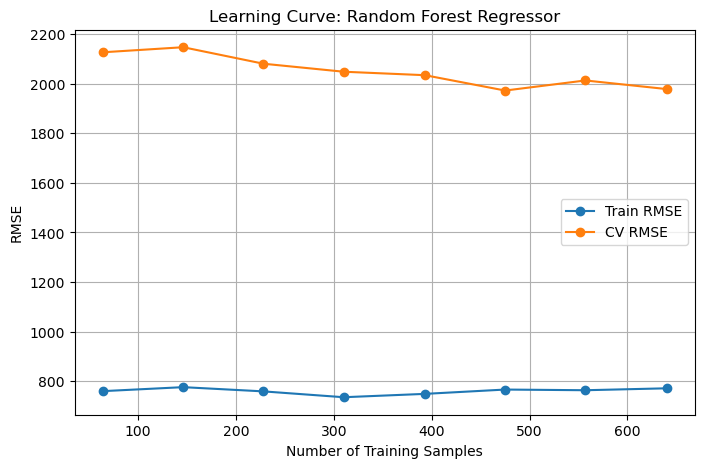

In [20]:
# Learning curve for Random Forest Regressor
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

rf = RandomForestRegressor(n_estimators=100, random_state=42)
train_sizes, train_scores, test_scores = learning_curve(
    rf, X_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_rmse = -np.mean(train_scores, axis=1)
test_rmse = -np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_rmse, 'o-', label='Train RMSE')
plt.plot(train_sizes, test_rmse, 'o-', label='CV RMSE')
plt.xlabel('Number of Training Samples')
plt.ylabel('RMSE')
plt.title('Learning Curve: Random Forest Regressor')
plt.legend()
plt.grid(True)
plt.show()

#### Understanding the Learning Curve

A learning curve shows how a model's performance changes as the size of the training set increases. It helps answer two key questions:
- **Do we have enough data?**
- **Is the model overfitting or underfitting?

**How to interpret the learning curve:**
- The **training score** (e.g., RMSE) shows how well the model fits the training data as more samples are added.
- The **validation (CV) score** shows how well the model generalizes to unseen data.

**Typical patterns:**
- If both training and validation errors are high and close together, the model is underfitting (too simple).
- If training error is much lower than validation error, the model is overfitting (too complex or not enough data).
- If both errors are low and close, the model is well-fit and you likely have enough data.
- If the validation error is still decreasing as more data is added, more data could help improve performance.

**In the plot above:**
- Compare the gap between the training and validation RMSE curves.
- If the gap is large, more data or regularization may help.
- If the validation curve flattens out, adding more data may not help much.

Learning curves are a powerful diagnostic tool for model selection and data collection decisions.